In [1]:
from modules import TGSupervisor
import torch

S = TGSupervisor()
s = S(torch.rand(128, 24, 24))
print(f"Supervisor output (windows, steps, latent): {tuple(s.shape)}   expect (128, 24, 24)")
print(f"Output range: {s.min():.3f} to {s.max():.3f}   expect within 0 to 1")
print(f"Parameters: {sum(p.numel() for p in S.parameters()):,}   expect 7,800")

H = torch.rand(128, 24, 24)
loss = torch.nn.functional.mse_loss(S(H)[:, :-1], H[:, 1:])
print(f"Untrained supervised loss: {loss.item():.4f}   expect roughly 0.08-0.12 (random guesses on [0,1] data)")

Supervisor output (windows, steps, latent): (128, 24, 24)   expect (128, 24, 24)
Output range: 0.436 to 0.593   expect within 0 to 1
Parameters: 7,800   expect 7,800
Untrained supervised loss: 0.0840   expect roughly 0.08-0.12 (random guesses on [0,1] data)


In [2]:
from modules import TGDiscriminator
D = TGDiscriminator()
d = D(torch.rand(128, 24, 24))
print(f"Discriminator output (windows, steps, score): {tuple(d.shape)}   expect (128, 24, 1)")
print(f"Output range: {d.min():.3f} to {d.max():.3f}   expect values outside 0-1 possible (logits, no sigmoid)")
print(f"Parameters: {sum(p.numel() for p in D.parameters()):,}   expect 10,825")

Discriminator output (windows, steps, score): (128, 24, 1)   expect (128, 24, 1)
Output range: 0.234 to 0.364   expect values outside 0-1 possible (logits, no sigmoid)
Parameters: 10,825   expect 10,825


In [5]:
from train import train_embedding
from modules import TGEmbedder, TGRecovery
from dataset import *
import torch
from dataset import get_data
train_loader, val_w, test_w, stats = get_data("~/Desktop/LOBSTER")

torch.manual_seed(0)
E, R = TGEmbedder(), TGRecovery()
hist, val_mse = train_embedding(E, R, train_loader, val_w, device="cpu", steps=1000)
print(f"Train recon MSE: start {hist[0]:.3f} -> end {hist[-1]:.3f}   expect start ~1.0, end well below")
print(f"Val recon MSE:   {val_mse:.3f}   expect close to train end; >> train end = overfitting")

phase 1  step   250  recon MSE 0.9745
phase 1  step   500  recon MSE 0.7921
phase 1  step   750  recon MSE 0.7481
phase 1  step  1000  recon MSE 0.7763
Train recon MSE: start 1.048 -> end 0.776   expect start ~1.0, end well below
Val recon MSE:   0.708   expect close to train end; >> train end = overfitting


In [6]:
for h in [24, 40, 64]:
    torch.manual_seed(0)
    E, R = TGEmbedder(hidden=h), TGRecovery(hidden=h)
    hist, val_mse = train_embedding(E, R, train_loader, val_w, device="cpu", steps=1000)
    print(f"hidden {h:3d}: train end {hist[-1]:.3f}   val {val_mse:.3f}   lower = latent keeps more information")

phase 1  step   250  recon MSE 0.9745
phase 1  step   500  recon MSE 0.7921
phase 1  step   750  recon MSE 0.7481
phase 1  step  1000  recon MSE 0.7763
hidden  24: train end 0.776   val 0.708   lower = latent keeps more information
phase 1  step   250  recon MSE 0.8269
phase 1  step   500  recon MSE 0.7126
phase 1  step   750  recon MSE 0.6769
phase 1  step  1000  recon MSE 0.6220
hidden  40: train end 0.622   val 0.699   lower = latent keeps more information
phase 1  step   250  recon MSE 0.7583
phase 1  step   500  recon MSE 0.6456
phase 1  step   750  recon MSE 0.5228
phase 1  step  1000  recon MSE 0.4469
hidden  64: train end 0.447   val 0.696   lower = latent keeps more information


In [7]:
with torch.no_grad():
    err = ((R(E(val_w)) - val_w) ** 2).mean(dim=(0, 1))       # MSE per feature (40 values)
cols = list(stats["mean"].index)
for group in ["ret", "spread", "ask_gap", "bid_gap", "ask_logv", "bid_logv"]:
    idx = [i for i, c in enumerate(cols) if c.startswith(group)]
    print(f"{group:<9} val recon MSE {err[idx].mean():.3f}   (1.0 = no better than predicting the average)")

ret       val recon MSE 0.429   (1.0 = no better than predicting the average)
spread    val recon MSE 0.409   (1.0 = no better than predicting the average)
ask_gap   val recon MSE 0.452   (1.0 = no better than predicting the average)
bid_gap   val recon MSE 0.465   (1.0 = no better than predicting the average)
ask_logv  val recon MSE 0.914   (1.0 = no better than predicting the average)
bid_logv  val recon MSE 0.961   (1.0 = no better than predicting the average)


In [8]:
for group in ["ret", "spread", "ask_gap", "bid_gap", "ask_logv", "bid_logv"]:
    idx = [i for i, c in enumerate(cols) if c.startswith(group)]
    print(f"{group:<9} val MSE of 'predict train average': {(val_w[..., idx] ** 2).mean():.3f}   (the real baseline to beat)")

ret       val MSE of 'predict train average': 0.584   (the real baseline to beat)
spread    val MSE of 'predict train average': 0.796   (the real baseline to beat)
ask_gap   val MSE of 'predict train average': 0.502   (the real baseline to beat)
bid_gap   val MSE of 'predict train average': 0.465   (the real baseline to beat)
ask_logv  val MSE of 'predict train average': 1.269   (the real baseline to beat)
bid_logv  val MSE of 'predict train average': 1.188   (the real baseline to beat)


In [9]:
torch.manual_seed(0)
E, R = TGEmbedder(), TGRecovery()                     # hidden=24 default
_ = train_embedding(E, R, train_loader, val_w, device="cpu", steps=1000)
with torch.no_grad():
    err = ((R(E(val_w)) - val_w) ** 2).mean(dim=(0, 1))
for group in ["ret", "spread", "ask_gap", "bid_gap", "ask_logv", "bid_logv"]:
    idx = [i for i, c in enumerate(cols) if c.startswith(group)]
    print(f"{group:<9} val recon MSE {err[idx].mean():.3f}   baseline (predict train average) {(val_w[..., idx] ** 2).mean():.3f}")

phase 1  step   250  recon MSE 0.9745
phase 1  step   500  recon MSE 0.7921
phase 1  step   750  recon MSE 0.7481
phase 1  step  1000  recon MSE 0.7763
ret       val recon MSE 0.447   baseline (predict train average) 0.584
spread    val recon MSE 0.328   baseline (predict train average) 0.796
ask_gap   val recon MSE 0.425   baseline (predict train average) 0.502
bid_gap   val recon MSE 0.360   baseline (predict train average) 0.465
ask_logv  val recon MSE 1.040   baseline (predict train average) 1.269
bid_logv  val recon MSE 1.008   baseline (predict train average) 1.188


In [11]:
import importlib, train
importlib.reload(train)
from train import train_supervisor

from train import train_supervisor
from modules import TGSupervisor
torch.manual_seed(0)
S = TGSupervisor()
hist, val_loss, persistence = train_supervisor(E, S, train_loader, val_w, device="cpu", steps=1000)
print(f"Train supervised MSE: start {hist[0]:.5f} -> end {hist[-1]:.5f}   expect a clear fall")
print(f"Val supervised MSE:   {val_loss:.5f}")
print(f"Persistence baseline: {persistence:.5f}   supervisor should be BELOW this to have learned dynamics")

phase 2  step   250  supervised MSE 0.01199
phase 2  step   500  supervised MSE 0.01169
phase 2  step   750  supervised MSE 0.01035
phase 2  step  1000  supervised MSE 0.01074
Train supervised MSE: start 0.02681 -> end 0.01074   expect a clear fall
Val supervised MSE:   0.00749
Persistence baseline: 0.01228   supervisor should be BELOW this to have learned dynamics


Reusing trained E, R, S from earlier cells
phase 3  step   100  D 1.352  G_adv 3.602  G_sup 0.01285  G_mom 0.553  E_rec 0.743
phase 3  step   200  D 0.610  G_adv 6.378  G_sup 0.01169  G_mom 0.466  E_rec 0.741
phase 3  step   300  D 0.528  G_adv 8.651  G_sup 0.01148  G_mom 0.433  E_rec 0.713
phase 3  step   400  D 0.566  G_adv 7.982  G_sup 0.01052  G_mom 0.418  E_rec 0.707
phase 3  step   500  D 0.843  G_adv 6.024  G_sup 0.01050  G_mom 0.437  E_rec 0.676
Generated windows: (697, 24, 40)   expect (697, 24, 40)
Any NaN in output: False   expect False
Metric                                     real (val)    generated  ref (train)   note
--------------------------------------------------------------------------------------------------------
Spread mean (ticks)                            11.381       12.291       13.029   
Spread std (ticks)                              3.598        4.618        4.440   
5s return std (bps)                             1.507        1.772        1.966   
Mean 

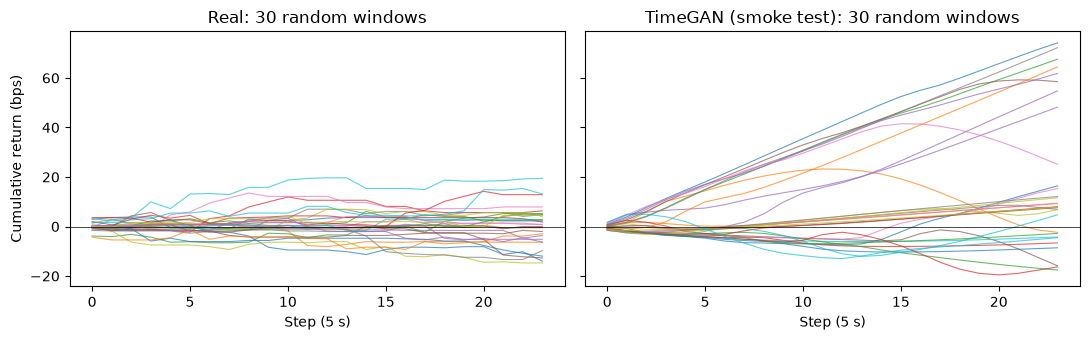

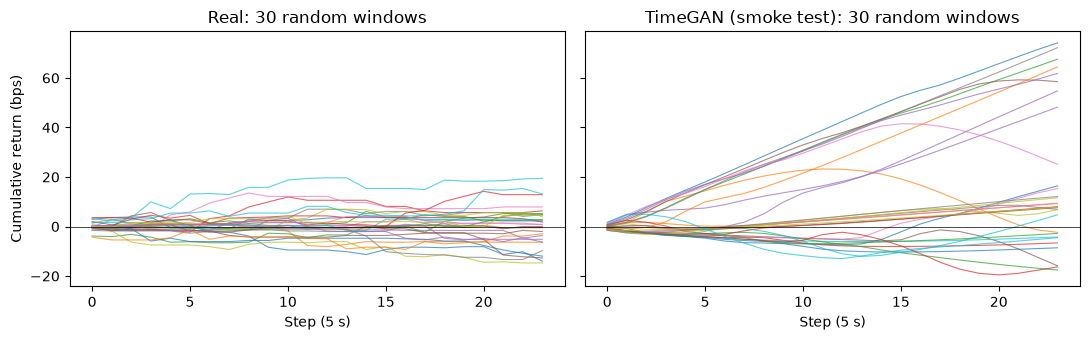

In [12]:
import importlib, torch
import train, modules, utils
importlib.reload(modules); importlib.reload(train); importlib.reload(utils)   # pick up your edits
from modules import TGEmbedder, TGRecovery, TGSupervisor, TGGenerator, TGDiscriminator, tg_generate
from train import train_embedding, train_supervisor, train_joint

# Phases 1 and 2: reuse E, R, S if they're still in memory, otherwise retrain them (~2 min)
try:
    E, R, S
    print("Reusing trained E, R, S from earlier cells")
except NameError:
    torch.manual_seed(0)
    E, R, S = TGEmbedder(), TGRecovery(), TGSupervisor()
    train_embedding(E, R, train_loader, val_w, device="cpu", steps=1000)
    train_supervisor(E, S, train_loader, val_w, device="cpu", steps=1000)

# Phase 3: joint training (smoke test, a few minutes)
torch.manual_seed(0)
G, D = TGGenerator(), TGDiscriminator()
hist3 = train_joint(E, R, G, S, D, train_loader, device="cpu", steps=500)

# Generate and score with the same code as the baseline
torch.manual_seed(0)
fake_tg = tg_generate(G, S, R, n=len(val_w))
print(f"Generated windows: {tuple(fake_tg.shape)}   expect ({len(val_w)}, 24, 40)")
print(f"Any NaN in output: {torch.isnan(fake_tg).any().item()}   expect False")
utils.print_report(utils.evaluate(val_w, fake_tg, stats, ref_w=train_loader.dataset.tensors[0]))
utils.plot_paths(val_w, fake_tg, stats, label="TimeGAN (smoke test)")